In [94]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42


sys.version_info(major=3, minor=14, micro=2, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.1
pandas 3.0.0
sklearn 1.8.0
torch 2.10.0+cu130
cuda:0


In [95]:
from torchvision import datasets
from torchvision.transforms import ToTensor, Resize, Compose, ConvertImageDtype, Normalize, RandomHorizontalFlip, RandomRotation
from torch.utils.data import random_split, Dataset
from pathlib import Path

# --- 1. 定义两种数据预处理流程 ---

# 预先设定的图片尺寸和标准化参数
img_h, img_w = 128, 128
norm_mean = [0.4363, 0.4328, 0.3291]
norm_std = [0.2085, 0.2032, 0.1988]

# 训练集的 transform，包含数据增强
train_transform = Compose([
    Resize((img_h, img_w)),
    RandomHorizontalFlip(), # 随机水平翻转
    RandomRotation(10),     # 随机旋转-10到10度
    ToTensor(),
    Normalize(norm_mean, norm_std),
    ConvertImageDtype(torch.float),
])

# 验证集的 transform，没有数据增强
val_transform = Compose([
    Resize((img_h, img_w)),
    ToTensor(),
    Normalize(norm_mean, norm_std),
    ConvertImageDtype(torch.float),
])

# --- 2. 创建一个包装类来正确应用变换 ---
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        # 从子集获取原始的、未变换的图像和标签
        x, y = self.subset[index]
        # 应用变换
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# --- 3. 从训练集切分训练/验证，并保留官方验证集作为测试 ---

DATA_DIR = Path("./archive/")
TRAIN_DIR = DATA_DIR / "training" / "training"
TEST_DIR = DATA_DIR / "validation" / "validation"

# 从 training 文件夹加载所有数据，不进行任何初始变换
full_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=None)
# 单独加载官方 validation 作为测试集
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=None)

# 确保类索引一致，避免标签错位
assert full_dataset.class_to_idx == test_dataset.class_to_idx

# 定义训练集和验证集的比例
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# 使用 random_split 进行切分，确保没有数据泄露
train_subset, val_subset = random_split(full_dataset, [train_size, val_size], torch.Generator().manual_seed(seed))

# 使用包装类将正确的变换应用于相应的子集
train_ds = TransformedSubset(train_subset, transform=train_transform)
val_ds = TransformedSubset(val_subset, transform=val_transform)
test_ds = TransformedSubset(test_dataset, transform=val_transform)

# 轻量级泄露检查：确认文件路径没有交集
train_paths = {full_dataset.samples[i][0] for i in train_subset.indices}
val_paths = {full_dataset.samples[i][0] for i in val_subset.indices}
test_paths = {p for p, _ in test_dataset.samples}
print("Overlap train/val:", len(train_paths & val_paths))
print("Overlap train/test:", len(train_paths & test_paths))
print("Overlap val/test:", len(val_paths & test_paths))

print(f"Total images: {len(full_dataset)}")
print(f"Training dataset size: {len(train_ds)}")
print(f"Validation dataset size: {len(val_ds)}")
print(f"Test dataset size: {len(test_ds)}")
print("Classes:", full_dataset.class_to_idx)

Overlap train/val: 0
Overlap train/test: 0
Overlap val/test: 0
Total images: 1097
Training dataset size: 877
Validation dataset size: 220
Test dataset size: 272
Classes: {'n0': 0, 'n1': 1, 'n2': 2, 'n3': 3, 'n4': 4, 'n5': 5, 'n6': 6, 'n7': 7, 'n8': 8, 'n9': 9}


In [96]:
# # 图片路径 及 标签
i=0
for fpath, label in train_ds.subset.dataset.samples:
    print(fpath, label)
    i += 1
    if i == 10:
        break
#
# #这个和之前的dataset完全一致
# for img, label in train_ds:
#     # c, h, w  label
#     print(img, label)
#     break

archive\training\training\n0\n0018.jpg 0
archive\training\training\n0\n0019.jpg 0
archive\training\training\n0\n0020.jpg 0
archive\training\training\n0\n0021.jpg 0
archive\training\training\n0\n0022.jpg 0
archive\training\training\n0\n0023.jpg 0
archive\training\training\n0\n0024.jpg 0
archive\training\training\n0\n0025.jpg 0
archive\training\training\n0\n0026.jpg 0
archive\training\training\n0\n0027.jpg 0


In [97]:
#因为有3通道，所有有3个mean和std
def cal_mean_std(ds):
    mean = 0.
    std = 0.
    for img, _ in ds:
        mean += img[:, :, :].mean(dim=(1, 2))
        std += img[:, :, :].std(dim=(1, 2))
    mean /= len(ds)
    std /= len(ds)
    return mean, std

# 经过 normalize 后 均值为0，方差为1
# print(cal_mean_std(train_ds))

In [98]:
import torch.nn as nn
from torch.utils.data.dataloader import DataLoader

batch_size = 64
# 从数据集到dataloader，num_workers参数不能加，否则会报错
# https://github.com/pytorch/pytorch/issues/59438
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [99]:
for imgs, labels in train_loader:
    print(imgs.shape)
    print(labels.shape)
    break

torch.Size([64, 3, 128, 128])
torch.Size([64])


In [100]:

class CNN(nn.Module):
    def __init__(self, num_classes=10, activation="relu"):
        super(CNN, self).__init__()
        self.activation = F.relu if activation == "relu" else F.selu
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding="same")
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding="same")
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same")
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding="same")
        self.conv5 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same")
        self.conv6 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding="same")
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        # --- 3. 在全连接层后加入 Dropout ---
        self.dropout = nn.Dropout(p=0.5) # 50% 的概率丢弃
        self.fc2 = nn.Linear(128, num_classes)

        self.init_weights()

    def init_weights(self):
        """使用 xavier 均匀分布来初始化全连接层、卷积层的权重 W"""
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Conv2d)):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        act = self.activation
        x = self.pool(act(self.conv2(act(self.conv1(x)))))
        x = self.pool(act(self.conv4(act(self.conv3(x)))))
        x = self.pool(act(self.conv6(act(self.conv5(x)))))
        x = self.flatten(x)
        x = act(self.fc1(x))
        # 在训练时，dropout层会起作用；在评估时(model.eval())，它会自动失效
        x = self.dropout(x)
        x = self.fc2(x)
        return x


for idx, (key, value) in enumerate(CNN().named_parameters()):
    print(f"{key}\tparamerters num: {np.prod(value.shape)}")


conv1.weight	paramerters num: 864
conv1.bias	paramerters num: 32
conv2.weight	paramerters num: 9216
conv2.bias	paramerters num: 32
conv3.weight	paramerters num: 18432
conv3.bias	paramerters num: 64
conv4.weight	paramerters num: 36864
conv4.bias	paramerters num: 64
conv5.weight	paramerters num: 73728
conv5.bias	paramerters num: 128
conv6.weight	paramerters num: 147456
conv6.bias	paramerters num: 128
fc1.weight	paramerters num: 4194304
fc1.bias	paramerters num: 128
fc2.weight	paramerters num: 1280
fc2.bias	paramerters num: 10


In [101]:
def count_parameters(model): #计算模型总参数量
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
count_parameters(CNN())

4482730

In [102]:
from sklearn.metrics import accuracy_score

@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    loss_list = []
    pred_list = []
    label_list = []
    for datas, labels in dataloader:
        datas = datas.to(device)
        labels = labels.to(device)
        # 前向计算
        logits = model(datas)
        loss = loss_fct(logits, labels)         # 验证集损失
        loss_list.append(loss.item())

        preds = logits.argmax(axis=-1)    # 验证集预测
        pred_list.extend(preds.cpu().numpy().tolist())
        label_list.extend(labels.cpu().numpy().tolist())

    acc = accuracy_score(label_list, pred_list)
    return np.mean(loss_list), acc


In [103]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch.
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir
        self.save_step = save_step
        self.save_best_only = save_best_only
        self.best_metrics = -1

        # mkdir
        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:
            return

        if self.save_best_only:
            assert metric is not None
            if metric >= self.best_metrics:
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt"))
                # update best metrics
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))



In [104]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped.. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.best_metric = -1
        self.counter = 0

    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            # update best metric
            self.best_metric = metric
            # reset counter
            self.counter = 0
        else:
            self.counter += 1

    @property
    def early_stop(self):
        return self.counter >= self.patience


In [91]:
# 训练
def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
    ):
    record_dict = {
        "train": [],
        "val": []
    }

    global_step = 0
    model.train()
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            # training
            for datas, labels in train_loader:
                datas = datas.to(device)
                labels = labels.to(device)
                # 梯度清空
                optimizer.zero_grad()
                # 模型前向计算
                logits = model(datas)
                # 计算损失
                loss = loss_fct(logits, labels)
                # 梯度回传
                loss.backward()
                # 调整优化器，包括学习率的变动等
                optimizer.step()
                preds = logits.argmax(axis=-1)

                acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
                loss = loss.cpu().item()
                # record

                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                })

                # evaluating
                if global_step % eval_step == 0:
                    model.eval()
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train()

                    # 1. 使用 tensorboard 可视化
                    # if tensorboard_callback is not None:
                    #     tensorboard_callback(
                    #         global_step,
                    #         loss=loss, val_loss=val_loss,
                    #         acc=acc, val_acc=val_acc,
                    #         lr=optimizer.param_groups[0]["lr"],
                    #         )

                    # 2. 保存模型权重 save model checkpoint
                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    # 3. 早停 Early Stop
                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                # udate step
                global_step += 1
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id})

    return record_dict


epoch = 20

activation = "relu"
model = CNN(num_classes=10, activation=activation)

# 1. 定义损失函数 采用交叉熵损失
loss_fct = nn.CrossEntropyLoss()
# 2. 定义优化器 采用 adam
# Optimizers specified in the torch.optim package
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, eps=1e-7)

# 1. tensorboard 可视化
# if not os.path.exists("runs"):
#     os.mkdir("runs")
# tensorboard_callback = TensorBoardCallback(f"runs/monkeys-cnn-{activation}")
# tensorboard_callback.draw_model(model, [1, 3, img_h, img_w])
# 2. save best
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")
save_ckpt_callback = SaveCheckpointsCallback(f"checkpoints/monkeys-cnn-{activation}", save_step=len(train_loader), save_best_only=True)
# 3. early stop
early_stop_callback = EarlyStopCallback(patience=5)

model = model.to(device)
record = training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    tensorboard_callback=None,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=len(train_loader)
    )

  0%|          | 0/280 [00:00<?, ?it/s]

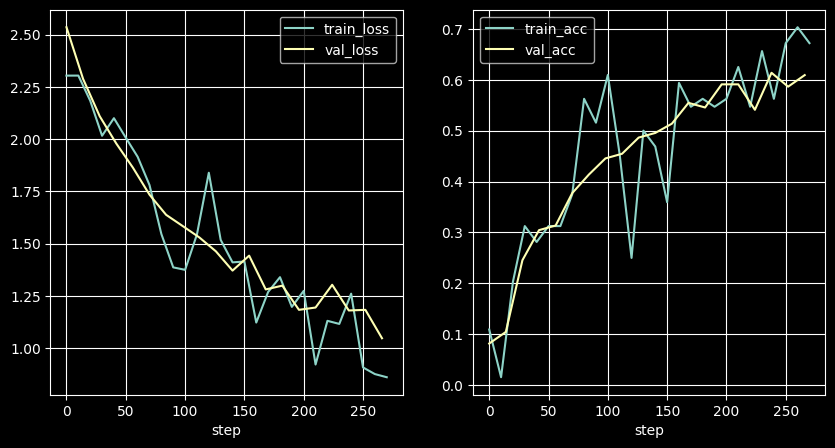

In [92]:
#画线要注意的是损失是不一定在零到1之间的
def plot_learning_curves(record_dict, sample_step=500):
    # build DataFrame
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # plot
    fig_num = len(train_df.columns)
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[idx].grid()
        axs[idx].legend()
        # axs[idx].set_xticks(range(0, train_df.index[-1], 5000))
        # axs[idx].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, train_df.index[-1], 5000)))
        axs[idx].set_xlabel("step")

    plt.show()

plot_learning_curves(record, sample_step=10)  #横坐标是 steps

In [93]:
# dataload for evaluating

# load checkpoints
model.load_state_dict(torch.load(f"checkpoints/monkeys-cnn-{activation}/best.ckpt", map_location="cpu"))

model.eval()
val_loss, val_acc = evaluating(model, val_loader, loss_fct)
print(f"val loss:     {val_loss:.4f}\nval accuracy: {val_acc:.4f}")

test_loss, test_acc = evaluating(model, test_loader, loss_fct)
print(f"test loss:    {test_loss:.4f}\ntest accuracy:{test_acc:.4f}")


val loss:     1.1796
val accuracy: 0.6136
test loss:    1.1635
test accuracy:0.5625
